In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_excel("task2_cleaned_weather_data.xlsx")
df["time"] = pd.to_datetime(df["time"])

print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Loaded: 1830 rows × 13 columns


In [2]:
# We'll predict mean temperature using these features
features = [
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "windspeed_10m_max",
    "relative_humidity_2m_mean",
    "month",
    "day_of_year",
]

target = "temperature_2m_mean"

X = df[features]
y = df[target]

print(f"Features : {features}")
print(f"Target   : {target}")
print(f"X shape  : {X.shape}")
print(f"y shape  : {y.shape}")

Features : ['temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'windspeed_10m_max', 'relative_humidity_2m_mean', 'month', 'day_of_year']
Target   : temperature_2m_mean
X shape  : (1830, 7)
y shape  : (1830,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

Training samples : 1464
Testing samples  : 366


In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")
print(f"\nIntercept : {model.intercept_:.4f}")
print("\nFeature Coefficients:")
for feat, coef in zip(features, model.coef_):
    print(f"  {feat:<35} {coef:.4f}")

Model trained successfully.

Intercept : 0.6821

Feature Coefficients:
  temperature_2m_max                  0.4287
  temperature_2m_min                  0.5829
  precipitation_sum                   -0.0200
  windspeed_10m_max                   -0.0050
  relative_humidity_2m_mean           -0.0121
  month                               -0.0318
  day_of_year                         0.0014


In [5]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("  MODEL EVALUATION")
print("=" * 40)
print(f"  MAE  (Mean Abs Error)  : {mae:.4f} °C")
print(f"  RMSE (Root Mean Sq Er) : {rmse:.4f} °C")
print(f"  R²   (Accuracy)        : {r2:.4f}")
print("=" * 40)

  MODEL EVALUATION
  MAE  (Mean Abs Error)  : 0.3050 °C
  RMSE (Root Mean Sq Er) : 0.3926 °C
  R²   (Accuracy)        : 0.9761


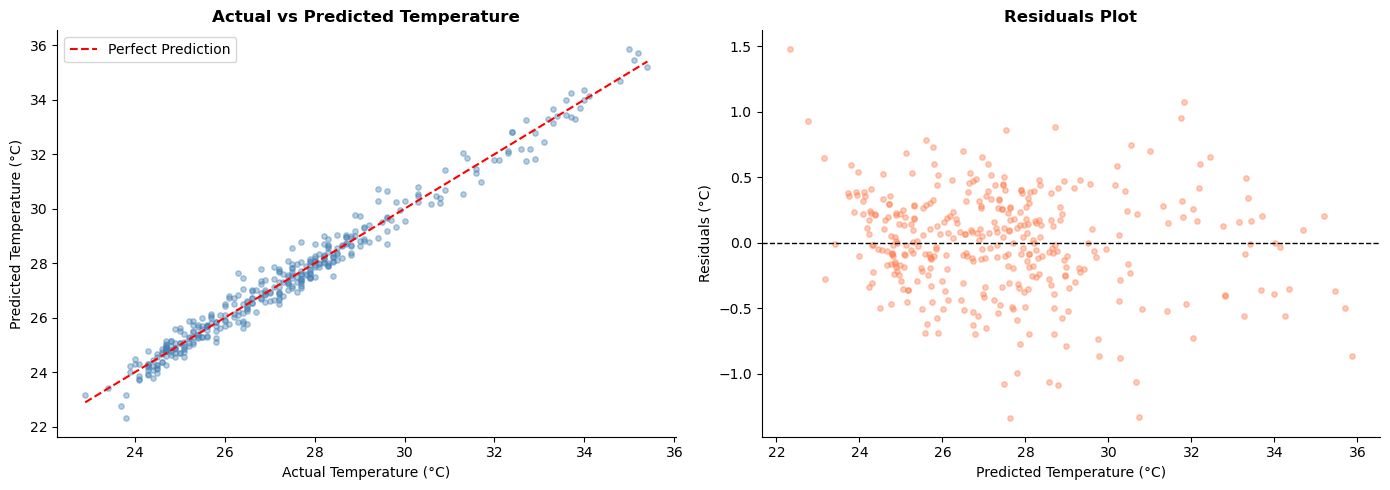

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=15)
axes[0].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 
             'r--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_xlabel("Actual Temperature (°C)")
axes[0].set_ylabel("Predicted Temperature (°C)")
axes[0].set_title("Actual vs Predicted Temperature", fontweight='bold')
axes[0].legend()

# Residuals plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color='coral', s=15)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel("Predicted Temperature (°C)")
axes[1].set_ylabel("Residuals (°C)")
axes[1].set_title("Residuals Plot", fontweight='bold')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("chart5a_actual_vs_predicted.png", dpi=150, bbox_inches='tight')
plt.show()

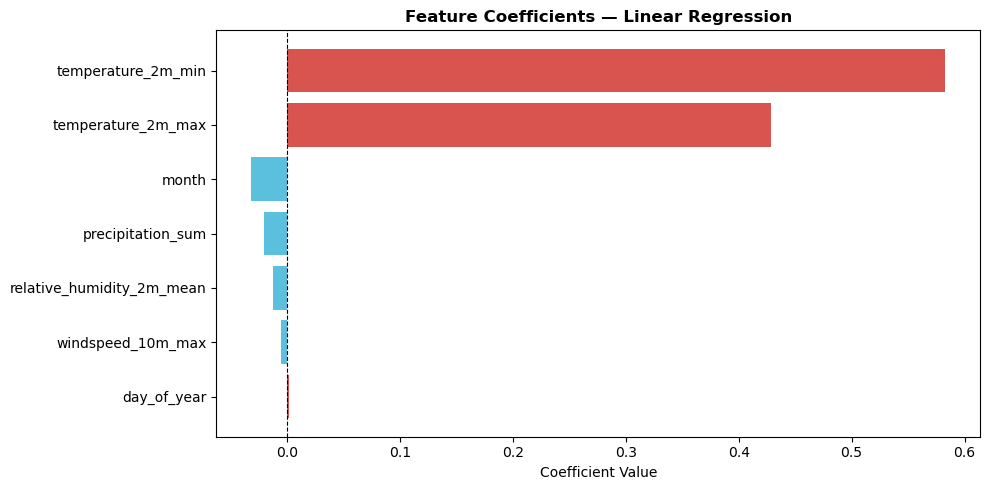

In [7]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
}).sort_values("Coefficient", key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#d9534f" if c > 0 else "#5bc0de" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("Feature Coefficients — Linear Regression", fontweight='bold')
ax.set_xlabel("Coefficient Value")

plt.tight_layout()
plt.savefig("chart5a_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

In [8]:
results_df = X_test.copy()
results_df["Actual_Temperature"]    = y_test.values
results_df["Predicted_Temperature"] = y_pred.round(2)
results_df["Residual"]              = (y_test.values - y_pred).round(2)

results_df.to_excel("task5a_regression_results.xlsx", index=False)
print("Saved: task5a_regression_results.xlsx")

Saved: task5a_regression_results.xlsx
